# **EXPLANATORY DATA ANALYSIS AND PRE-PROCESSING**

**Dian Rakhmawati Lestari - 2802539085**

In [ ]:
# Upload Dataset to Google Colab
from google.colab import files

files.upload()

Saving gender_submission.csv to gender_submission (3).csv
Saving test.csv to test (3).csv
Saving train.csv to train (3).csv


{'gender_submission (3).csv': b'PassengerId,Survived\r\n892,0\r\n893,1\r\n894,0\r\n895,0\r\n896,1\r\n897,0\r\n898,1\r\n899,0\r\n900,1\r\n901,0\r\n902,0\r\n903,0\r\n904,1\r\n905,0\r\n906,1\r\n907,1\r\n908,0\r\n909,0\r\n910,1\r\n911,1\r\n912,0\r\n913,0\r\n914,1\r\n915,0\r\n916,1\r\n917,0\r\n918,1\r\n919,0\r\n920,0\r\n921,0\r\n922,0\r\n923,0\r\n924,1\r\n925,1\r\n926,0\r\n927,0\r\n928,1\r\n929,1\r\n930,0\r\n931,0\r\n932,0\r\n933,0\r\n934,0\r\n935,1\r\n936,1\r\n937,0\r\n938,0\r\n939,0\r\n940,1\r\n941,1\r\n942,0\r\n943,0\r\n944,1\r\n945,1\r\n946,0\r\n947,0\r\n948,0\r\n949,0\r\n950,0\r\n951,1\r\n952,0\r\n953,0\r\n954,0\r\n955,1\r\n956,0\r\n957,1\r\n958,1\r\n959,0\r\n960,0\r\n961,1\r\n962,1\r\n963,0\r\n964,1\r\n965,0\r\n966,1\r\n967,0\r\n968,0\r\n969,1\r\n970,0\r\n971,1\r\n972,0\r\n973,0\r\n974,0\r\n975,0\r\n976,0\r\n977,0\r\n978,1\r\n979,1\r\n980,1\r\n981,0\r\n982,1\r\n983,0\r\n984,1\r\n985,0\r\n986,0\r\n987,0\r\n988,1\r\n989,0\r\n990,1\r\n991,0\r\n992,1\r\n993,0\r\n994,0\r\n995,0\r\n996,1\r\

**Data Dictionary:**
* **Survived:** Status keselamatan penumpang (0 = No (Tidak selamat), 1 = Yes (Selamat)).
* **Pclass:** Kelas tiket penumpang (1 = 1st, 2 = 2nd, 3 = 3rd).
* **Sex:** Jenis kelamin penumpang.
* **Age:** Usia penumpang dalam tahun.
* **SibSp:** Jumlah saudara kandung atau pasangan yang ikut dalam perjalanan.
* **Parch:** Jumlah orang tua atau anak yang ikut dalam perjalanan.
* **Ticket:** Nomor tiket penumpang.
* **Fare:** Harga tiket yang dibayarkan.
* **Cabin:** Nomor kabin penumpang.
* **Embarked:** Pelabuhan keberangkatan (C = Cherbourg, Q = Queenstown, S = Southampton).

In [ ]:
# kalo disconnect harus upload ulang
# Import dataset

import pandas as pd

train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

print(train_data.shape)
print(test_data.shape)

(891, 12)
(418, 11)


Output di atas menunjukkan bahwa dataset training memiliki **891 baris** dan **12 fitur**, sedangkan dataset testing memiliki **418 baris** dan **11 fitur**. Perbedaan jumlah fitur disebabkan karena dataset testing tidak memiliki kolom target `Survived`.

In [ ]:
# tampilkan bentuk dataset
# show the dataset in training data

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Memuat data lebih jelas pada data **train**.

In [ ]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Memuat data lebih jelas pada data **test**.

In [ ]:
# Drop Column passengerId, name, ticket, and cabin

cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

train_data = train_data.drop(columns=cols_to_drop)
test_data = test_data.drop(columns=cols_to_drop)

Fitur `PassengerId`, `Name`, `Ticket`, dan `Cabin` dihapus karena mengandung nilai unik yang terlalu banyak (*high cardinality*) atau informasi teks yang tidak memberikan pola prediktif yang kuat. Langkah ini krusial untuk mencegah *overfitting* dan membuat model lebih efisien.

In [ ]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Hasil data **train** setelah menghapus variable  `PassengerId`, `Name`, `Ticket`, dan `Cabin`.

In [ ]:
test_data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


Hasil data **test** setelah menghapus variable  `PassengerId`, `Name`, `Ticket`, dan `Cabin`.

# **Explanatory Data Analysis (EDA)**

In [ ]:
# identify training data structures

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


Berdasarkan informasi di atas, data train memiliki tipe data 2 float (`Age` dan `Fare`), 3 integer (`Pclass`, `SibSp`, dan `Parch`), serta 2 object/kategorikal (`Sex` dan `Embarked`). Pada data train `train_data.info()`, ditemukan adanya data kosong (*missing values*) pada fitur `Age` (19.87%) dan `Embarked` (0.22%). Karena jumlahnya cukup banyak (terutama `Age`), kita tidak bisa menghapus barisnya begitu saja. Kita perlu melakukan **imputasi** (mengisi nilai kosong) agar algoritma Machine Learning tidak mengalami error saat proses training.

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 23.0+ KB


Berdasarkan hasil `test_data.info()`, data test terdiri dari 418 baris dan 7 kolom tanpa variabel `Survived` karena kolom tersebut merupakan target yang harus diprediksi. Tipe datanya terdiri dari 2 float (`Age` dan `Fare`), 3 integer (`Pclass`, `SibSp`, dan `Parch`), serta 2 object/kategorikal (`Sex` dan `Embarked`).

Ditemukan missing values pada fitur `Age` sebesar 20,57% dan pada `Fare` sebesar 0,24%. Karena proporsi data kosong pada `Age` cukup besar, penghapusan baris bukanlah solusi yang tepat sehingga perlu dilakukan  **imputasi** (mengisi nilai kosong), agar algoritma Machine Learning tidak mengalami error saat proses testing.

### **EDA Non-Graphical**

In [ ]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* **count:** Baris ini menunjukkan berapa banyak data yang tidak kosong di setiap kolom. Terlihat kolom `Age` hanya memiliki 714 data, yang seharusnya memiliki 891 data, ini menunjukkan adanya data yang hilang.

* **mean:** Menunjukkan nilai rata-rata. Sekitar 38% penumpang selamat (nilai 0.38), mayoritas kelas penumpang adalah 2.3 (didominasi kelas menengah ke bawah), dan mayoritas penumpang berusia sekiar 29.7 tahun.

* **std (Standard Deviation):** Menunjukkan seberapa jauh data tersebar dari rata-rata. Kolom `Fare` (harga tiket) memiliki std yang sangat tinggi (49.69), menandakan perbedaan harga tiket antar penumpang yang sangat ekstrem. Nilai standar deviasi yang besar, khususnya pada `Fare`, menunjukkan penyebaran data yang lebar dan kemungkinan adanya **outlier**.

* **min:** Nilai terkecil. Penumpang termuda adalah bayi berusia 0.42 tahun (sekitar 5 bulan). Ada juga tiket seharga 0, menunjukkan beberapa penumpang naik secara gratis.

* **25% (Kuartil 1):** Sebanyak 25% penumpang berusia 20.1 tahun ke bawah, mayoritas di kelas 2 atau 3, dan membayar tiket 7.91 atau kurang. Ini menunjukkan populasi besar penumpang muda dengan tiket murah.

* **50% (Median):** Nilai tengah data. Setengah dari penumpang berusia 28 tahun ke bawah dan berada di kelas 3. Karena median `Survived` adalah 0, ini berarti lebih dari separuh penumpang tidak selamat.

* **75% (Kuartil 3):** Sebanyak 75% penumpang berusia 38 tahun ke bawah dan membayar tiket maksimal 31.00.

* **max:** Nilai tertinggi. Penumpang tertua berusia 80 tahun. Tiket termahal mencapai 512.33, yang merupakan Outlier (nilai ekstrem) karena jauh melampaui rata-rata harga tiket.

In [ ]:
train_data.describe(include=object)

,Sex,Embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


* **count:** Menunjukkan jumlah data yang terisi. Kolom `Sex` lengkap (891), sedangkan `Embarked` kehilangan 2 data (889).
* **unique:** Jumlah kategori unik. Ada 2 jenis kelamin (male/female) dan 3 pelabuhan keberangkatan (C, Q, S) -> C = Cherbourg, Q = Queenstown, S = Southampton.
* **top:** Kategori yang paling sering muncul. Mayoritas penumpang adalah laki-laki (male) dan kebanyakan naik dari pelabuhan S (Southampton).
* **freq (Frequency):** Menunjukkan jumlah kemunculan nilai tertinggi. Ada 577 laki-laki di kapal, dan 644 orang naik dari Southampton. Ini memberikan gambaran dominasi profil penumpang tertentu.

In [ ]:
# Check missing values

missing_summary_train = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage': (train_data.isnull().sum().mean() * 100).round(2)
})

missing_summary_train

,Missing Count,Missing Percentage
Survived,0,2237.5
Pclass,0,2237.5
Sex,0,2237.5
Age,177,2237.5
SibSp,0,2237.5
Parch,0,2237.5
Fare,0,2237.5
Embarked,2,2237.5


**Missing Count:** Kolom ini menunjukkan jumlah baris yang kosong pada setiap fitur. Terlihat bahwa fitur **Age** memiliki 177 data kosong, dan fitur **Embarked** memiliki 2 data kosong.

**Missing Percentage:** Kolom ini menunjukkan proporsi data yang hilang dalam bentuk persentase.
* Fitur **Age** kehilangan sekitar **19.87%** datanya. Ini adalah angka yang cukup signifikan, sehingga diperlukan **imputasi** (mengisi nilai kosong).
* Fitur **Embarked** hanya kehilangan **0.22%** data, yang tergolong sangat kecil dan mudah untuk ditangani.
* Fitur lainnya memiliki **0.00%** missing values, yang berarti data pada kolom tersebut sudah lengkap dan bersih.

## **EDA Multivariate Non-Graphical**

In [ ]:
# Cross Tabulation
# embarked -> C = Cherbourg, Q = Queenstown, S = Southampton

sex_embarked_ct = pd.crosstab(
    train_data['Sex'],
    train_data['Embarked'],
    dropna = False
)

sex_embarked_ct

Embarked,C,Q,S,NaN
Sex,,,,
female,73,36,203,2
male,95,41,441,0


Tabel ini menunjukkan hubungan antara jenis kelamin (**Sex**) dan pelabuhan keberangkatan (**Embarked**):
* **Southampton (S):** Merupakan pelabuhan tersibuk dengan jumlah penumpang terbanyak, didominasi oleh laki-laki (441 orang) dibandingkan perempuan (203 orang).
* **Cherbourg (C):** Memiliki distribusi yang lebih berimbang antara laki-laki (95) dan perempuan (73).
* **Queenstown (Q):** Memiliki jumlah penumpang paling sedikit dengan 41 laki-laki dan 36 perempuan.

Kita bisa melihat adanya 2 data kosong (NaN) pada penumpang perempuan yang tidak mencantumkan pelabuhan keberangkatan. Data ini nantinya akan kita isi menggunakan nilai modus (S).

### **Univariate Graphical**
#### Melihat distribusi survived dan non-survived

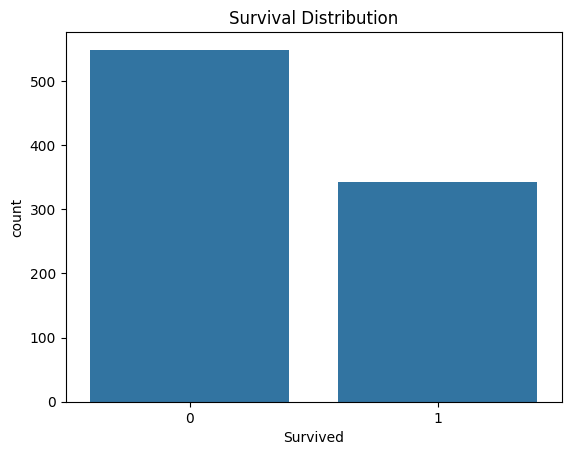

In [ ]:
# Bar Chart for Survival Distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=train_data)
plt.title('Survival Distribution')
plt.show()

**Survival Distribution:** Grafik menunjukkan dataset tidak seimbang (*imbalanced*), di mana jumlah korban jiwa (0) lebih banyak dibanding yang selamat (1).

Text(0.5, 1.0, 'Age Distribution')

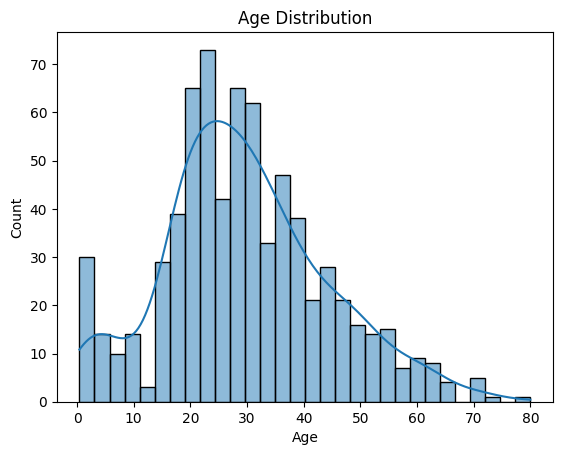

In [ ]:
# Histogram for Age Distribution
# positive skew, maka mayoritas passenger berumur sekitar 29.6

sns.histplot(train_data['Age'], bins=30, kde=True)
plt.title('Age Distribution')

**Age Distribution:** Distribusi usia bersifat *right-skewed*. Terlihat mayoritas penumpang kapal berusia **20-35 tahun**, namun ada "puncak" kecil pada kategori balita yang menunjukkan keberadaan anak-anak di kapal.

## **EDA Multivariate Graphical**

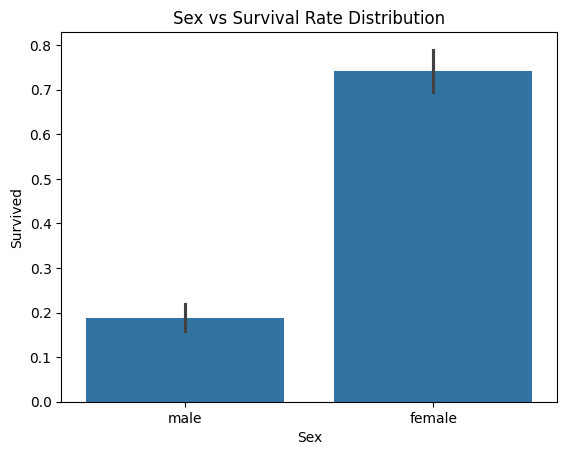

In [ ]:
# Sex vs Survived Distribution

sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title('Sex vs Survival Rate Distribution')
plt.show()

**Sex vs Survived:** Grafik bar menunjukkan perbedaan yang drastis pada tingkat keselamatan. Perempuan memiliki tingkat keselamatan jauh lebih tinggi dibanding laki-laki. Ini membuktikan bahwa wanita didahulukan saat evakuasi.

Text(0.5, 1.0, 'Age vs Survival Distribution')

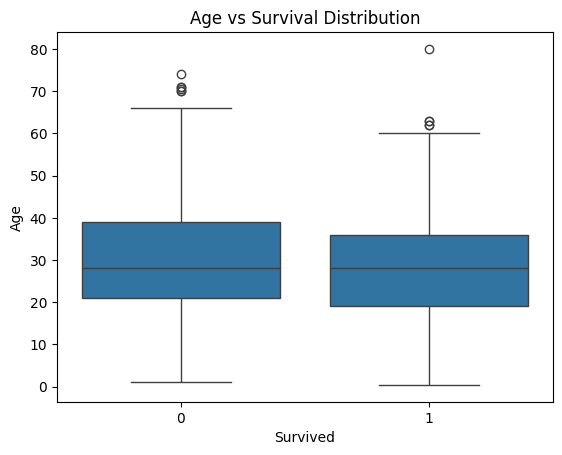

In [ ]:
# Age vs Survived Distribution
# Bisa menggunaan BoxPlot

sns.boxplot(x='Survived', y='Age', data=train_data)
plt.title('Age vs Survival Distribution')

**Age vs Survived (Boxplot):** Median usia yang selamat (1) sedikit lebih rendah. Boxplot mendeteksi banyak *outliers* pada kelompok selamat, yang mengonfirmasi prioritas penyelamatan pada usia muda dan anak-anak (*Women and children first*).

# **Data Pre-Processing**

In [ ]:
# Age impution with Mean

train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())

Missing value `Age` diisi dengan nilai **Mean (Rata-rata)** karena umur adalah data numerik yang distribusi nya cukup padat.


In [ ]:
# Embarked Imputation with Mode/Modus

train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

Missing value Pelabuhan Keberangkatan(`Embarked`) karena hanya 2 data yang hilang diisi menggunakan **Modus (Nilai yang paling sering muncul)** karena umur adalah data kategorikal, maka diisi dengan nilai yang paling sering muncul.

In [ ]:
# Re-check missing-values

train_data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Setelah proses mengisi missing value bisa dilihat sekarang sudah tidak ada lagi data yang hilang atau tidak terisi.

In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Sex', 'Embarked']:
  train_data[col] = le.fit_transform(train_data[col])

Label Encoding mengubah kategori `Sex` dan `Embarked` menjadi angka agar bisa diproses algoritma dan komputer, contohnya (`Male/Female`) menjadi 0 dan 1.

In [ ]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


Menunjukkan bahwa seluruh variabel kategorikal telah berhasil ditransformasikan ke dalam bentuk numerik sehingga dapat diproses dan dipahami oleh algoritma komputer.

In [ ]:
# Data Transformation using Standar Scaler (Z-Score)
# Variable Age dan Fare perlu dinormalisasi agar seimbang

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols= ['Age', 'Fare']

train_data[scale_cols] = scaler.fit_transform(train_data[scale_cols])

Standard Scaling (Z-Score) menstandarisasi fitur `Age` dan `Fare` sehingga memiliki rata-rata 0 dan standar deviasi 1. Metode ini tidak membatasi nilai pada rentang tertentu, tetapi menyesuaikan distribusi berdasarkan penyimpangan dari rata-ratanya. Proses ini penting agar fitur dengan skala besar seperti `Fare` tidak mendominasi perhitungan model dibandingkan fitur dengan skala lebih kecil, terutama pada algoritma yang sensitif terhadap perbedaan skala.

In [ ]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,-0.592481,1,0,-0.502445,2
1,1,1,0,0.638789,1,0,0.786845,0
2,1,3,0,-0.284663,0,0,-0.488854,2
3,1,1,0,0.407926,1,0,0.420730,2
4,0,3,1,0.407926,0,0,-0.486337,2


Hasil standarisasi variable umur(`Age`) dan tarif(`Fare`)

## **Feature Correlation Heatmap**

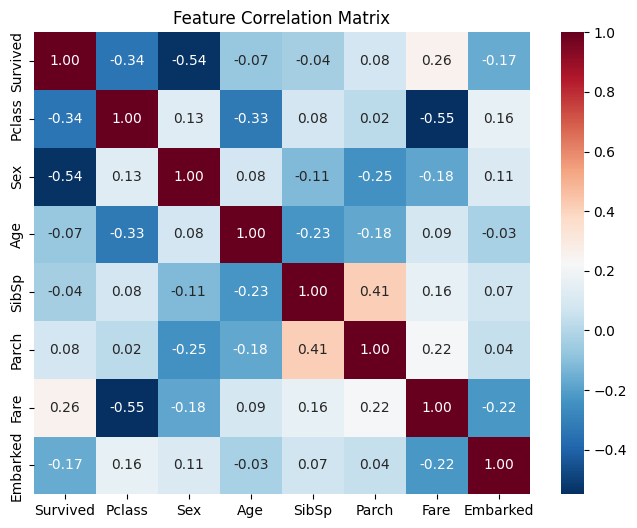

In [ ]:
# Feature Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(train_data.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

Heatmap ini menampilkan ringkasan hubungan antar seluruh variabel. Terlihat adanya korelasi negatif yang cukup kuat antara `Sex` dan `Survived`, yang mengindikasikan bahwa jenis kelamin merupakan salah satu prediktor paling signifikan dalam menentukan keselamatan penumpang.